In [2]:
############################ 0. PREPARATION ############################

#-------------------------- import packages --------------------------
import random
import os
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from itertools import combinations
import seaborn as sns
import copy
import itertools

import tensorflow as tf
import tensorflow_lattice as tfl
from tensorflow import keras
from keras.models import Sequential, Model
from keras.layers import Dense, Input, Multiply, Add, Embedding, Reshape, Concatenate, Dropout, BatchNormalization, Lambda, Layer, CategoryEncoding, Activation
from keras.constraints import Constraint
from keras.callbacks import EarlyStopping
from keras.initializers import Zeros, Constant
from keras.optimizers.legacy import Adam, Nadam, RMSprop
from keras.models import clone_model
import keras_tuner as kt
from keras import backend as K
from keras import regularizers
from keras.utils import plot_model
from keras.losses import Poisson, Loss
from keras.metrics import MeanAbsoluteError, RootMeanSquaredError
from scipy.stats import gamma


from pygam import LinearGAM, GAM, s, f, l
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_transformer
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error as mae
from sklearn.tree import DecisionTreeRegressor
from interpret.glassbox import ExplainableBoostingClassifier

In [3]:
#-------------------------- for reproducibility --------------------------
seed_value = 2024
keras.utils.set_random_seed(seed_value)

In [4]:
#-------------------------- import data --------------------------
data = pd.read_csv("data/synthetic_high_var_100.csv")

In [5]:
#-------------------------- remove outliers --------------------------
log_claim = np.log(data['Y'])
IQR = log_claim.quantile(0.75) - log_claim.quantile(0.25) # inter-quartile range
lower_whisker = log_claim.quantile(0.25)- 1.5*IQR
upper_whisker = log_claim.quantile(0.75) + 1.5*IQR

# remove outliers: filter rows where the log of 'Y' is within the whiskers
dt_cleaned = data[(log_claim >= lower_whisker) & (log_claim <= upper_whisker)]
dt_cleaned

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X92,X93,X94,X95,X96,X97,X98,X99,X100,Y
0,0.097627,-0.384709,0.070514,0.245303,-0.564460,-0.450318,0.531209,-0.139983,-0.999956,0.009359,...,-0.908374,0.886066,-0.819173,0.004835,0.908827,0.834917,0.174290,-0.110614,0.272404,86.862785
1,0.430379,-0.875990,0.808088,0.648436,0.174499,-0.765558,-0.898927,-0.168761,0.081209,-0.263657,...,0.724660,0.641338,0.891459,-0.333646,-0.224661,-0.573908,-0.138086,0.121118,0.892238,0.270987
2,0.205527,0.977570,0.004793,-0.431433,0.975227,0.473320,0.995090,0.794291,-0.802390,-0.861454,...,-0.376824,0.891913,0.950448,-0.680385,0.504282,0.006721,0.571587,0.838042,0.716258,0.372937
3,0.089766,0.438181,-0.798260,0.756793,0.901734,0.431272,-0.864656,0.512576,0.085770,-0.545924,...,-0.116147,0.665457,-0.672843,0.041874,-0.927594,-0.830077,0.443445,0.517565,0.406555,37.111393
4,-0.152690,0.515139,0.055164,0.282328,-0.314057,0.639535,-0.581069,0.940797,-0.261984,-0.425629,...,-0.380062,0.168792,0.447170,-0.082266,0.590256,-0.605521,-0.597518,-0.697405,0.626928,1.065084
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,0.092658,0.451842,0.805609,-0.262674,0.758215,-0.205461,0.443849,-0.978784,0.740276,0.645713,...,-0.699826,0.980132,0.679815,-0.098229,-0.218324,0.759831,0.095869,-0.111240,-0.613531,1104.815027
49996,0.386621,0.015041,-0.538708,-0.389854,-0.632906,-0.311577,0.027367,-0.845545,0.010439,0.868084,...,0.126862,0.657439,-0.033529,0.165377,-0.037332,0.317743,-0.619282,-0.290118,-0.357123,9.266537
49997,-0.532650,0.620266,0.162028,-0.570751,0.005453,0.235543,0.099723,0.663875,0.851769,0.066433,...,0.800202,0.147365,-0.763922,-0.836506,0.724906,-0.646295,-0.620084,0.703757,-0.451408,7.508186
49998,0.661848,0.102065,-0.526136,-0.408447,0.373860,-0.328123,0.756798,-0.514888,0.618938,0.761628,...,-0.936194,-0.304629,-0.488948,-0.353605,0.155388,-0.780283,-0.396183,0.747576,0.785282,0.021526


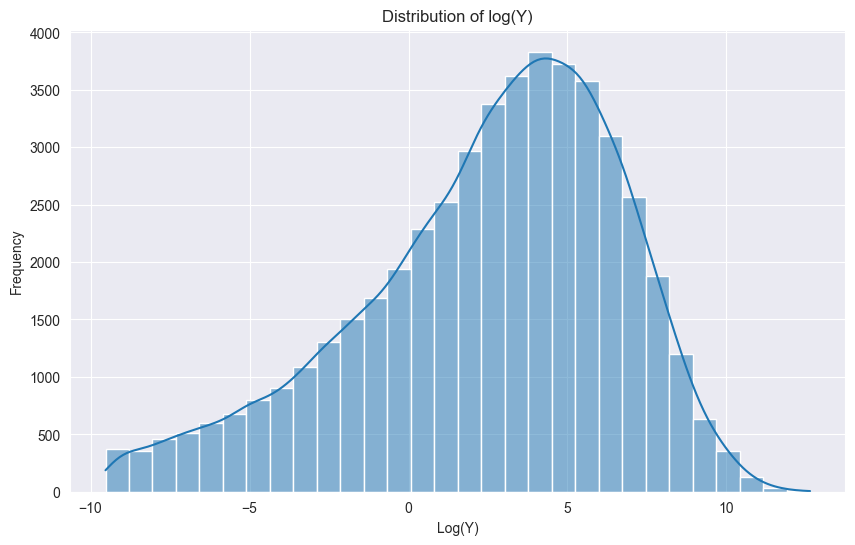

In [6]:
#-------------------------- distribution of log(response) --------------------------
plt.figure(figsize = (10, 6)) # set the size of the figure
sns.set_style("darkgrid")
sns.histplot(np.log(dt_cleaned['Y']), bins = 30, kde = True) # draw the chart
plt.title('Distribution of log(Y)')
plt.xlabel('Log(Y)')
plt.ylabel('Frequency')
plt.tick_params(axis = 'x')
plt.tick_params(axis = 'y')
plt.grid(True)
plt.show()

In [7]:
#-------------------------- column lists --------------------------
target_var = "Y" # target feature
all_vars = list(dt_cleaned.columns)
all_vars.remove(target_var) # store all input features
cat_vars = [] # categorical features

In [8]:
############################ 1. MAIN EFFECT SELECTION ############################

#-------------------------- train-test split --------------------------
X_main, X_test, y_main, y_test = train_test_split(
    dt_cleaned[all_vars], dt_cleaned[["Y"]], test_size = 0.2, random_state = 1)
X_train, X_val, y_train, y_val  = train_test_split(
    X_main, y_main, test_size = 0.25, random_state = 1)

In [9]:
# -------------------------- function to create a subnetwork --------------------------
# subnet for numerical variables
def create_subnet(num_layers, units_first_layer, activation, model_name, dropout_rate = 0, trainable = True, seed = 1):
    model = Sequential(name = model_name)
    for i in range(num_layers):
        num_units = units_first_layer - i*int(units_first_layer/num_layers)
        model.add(Dense(num_units, activation = activation, trainable = trainable))
        model.add(Dropout(dropout_rate, seed = seed))
    model.add(Dense(1, trainable = trainable))
    model.add(BatchNormalization(scale = False)) # for identifiability
    return model

In [10]:
# -------------------------- custom loss function --------------------------
def gamma_nll(y_true, y_pred):
    y_pred = K.clip(y_pred, 1e-7, 1e30)
    return K.mean(y_true/y_pred - K.log(y_true/y_pred))

In [11]:
#-------------------------- prepare the data for NAM --------------------------
X_train_split = []
X_val_split = []
for i in range(X_train.shape[1]):
    X_train_split.append(X_train.iloc[:, i])
    X_val_split.append(X_val.iloc[:, i])

In [13]:
# -------------------------- Fit an ensemble of 10 NAMs --------------------------
seed = 0
num_models = 10
all_variance = []

# track the time to select the main effects
_start_time = time.time()

# create ensemble and get subnet variance
for i in range(num_models):
    
    keras.utils.set_random_seed(seed)

    # -------------------------- define model architecture --------------------------
    inputs = []  # input layers
    sub_outputs_main = []  # main effect subnet output
    num_neurons_main = 20
    num_layers_main = 2
    activation = 'leaky_relu'
    keypoints = 10
    monotonicity_list = {"X3" : "decreasing"} # either "increasing", "decreasing", or "none"

    # main effect
    for name in all_vars:

        # input layer
        input_layer = Input(shape = (1,), name = name)
        inputs.append(input_layer)

        # subnetworks for main effects
        if name in cat_vars: # categorical variables
            # categorical variables will be one-hot encoded
            embed_layer = Embedding(input_dim = X_train[name].nunique(), 
                                    output_dim = 1, 
                                    name = f"{name}_embed")(input_layer)
            embed_layer_reshape = Reshape(target_shape = (1,), name = f"{name}_reshape")(embed_layer)
            mean_layer = BatchNormalization(scale = False, name = f"{name}_mean")(embed_layer_reshape)
            sub_outputs_main.append(mean_layer)
        elif name in monotonicity_list: # variables with monotonicity constraint
            calibrator_layer = tfl.layers.PWLCalibration(
                input_keypoints =  np.linspace(X_train[name].min(), X_train[name].max(), num = keypoints), # keypoints
                monotonicity = monotonicity_list[name], # monotonicity constraint
                name = f"{name}_pwlcalibrator"
            )(input_layer)
            mean_layer = BatchNormalization(scale = False, name = f"{name}_mean")(calibrator_layer)
            sub_outputs_main.append(mean_layer)
        else: # numeric variables
            subnet = create_subnet(num_layers_main, num_neurons_main, activation, f"{name}_subnetwork")
            sub_output = subnet(input_layer)
            sub_outputs_main.append(sub_output)

    # combine subnets' outputs and create model
    main_subnets = Concatenate(name = "main_subnet")(sub_outputs_main)
    final_output = Dense(1, activation = "exponential", name = "main_output")(main_subnets)
    model_all_vars = Model(inputs = inputs, outputs = final_output)

    # -------------------------- fit the model --------------------------
    model_all_vars.compile(optimizer = "adam", loss = gamma_nll, metrics = [RootMeanSquaredError(), MeanAbsoluteError()])
    es = EarlyStopping(restore_best_weights = True, patience = 10)
    model_all_vars.fit(X_train_split, y_train, epochs = 5_000, \
        callbacks = [es], batch_size = 5_000, validation_data = (X_val_split, y_val), verbose = 0)
    

    # -------------------------- quantify variable importance --------------------------
    main_output_layer = model_all_vars.get_layer("main_subnet")  # Get the subnet output layer
    main_model = Model(inputs = model_all_vars.inputs, outputs = main_output_layer.output)
    main_output_values = main_model.predict(X_train_split, batch_size = 5_000)

    # Get the variance of each subnetwork across all data points
    subnet_weights = model_all_vars.get_layer("main_output").get_weights()[0]
    subnet_variance = [np.var(main_output_values[:, i])*subnet_weights[i][0]**2 for i in range(main_output_values.shape[1])]
    all_variance.append(subnet_variance)

    # update seed
    seed += 1

# Compute the time to execute the codes
_end_time = time.time()
main_effect_time = _end_time - _start_time
print(f"Execution time: {main_effect_time:.2f} seconds")

6/6 [==============================] - 1s 10ms/step
Execution time: 2077.32 seconds


In [ ]:
# -------------------------- evaluate the variable importance --------------------------
average_variances = np.mean(all_variance, axis = 0) # get the average variance

# Create DataFrame for variable importance
var_importance = pd.DataFrame({"Covariates": all_vars, "Subnet Variance": average_variances})

# Sort the DataFrame by subnet variance in decreasing order
varimp_sorted = var_importance.sort_values(by = "Subnet Variance", ascending = False)

# View the output
varimp_sorted[0:15]

,Covariates,Subnet Variance
5,X6,0.072221
1,X2,0.067626
4,X5,0.061828
2,X3,0.054348
3,X4,0.039119
6,X7,0.024148
0,X1,0.022523
7,X8,0.010563
20,X21,0.009031
95,X96,0.008854
